# Inference and analysis of cell-cell communication using MultiChat

> This tutorial provides a step-by-step guide to performing spatial cell–cell communication (CCC) analysis using the MultiChat framework. Using the spatial ATAC–RNA-seq data of mouse brain tissue as a case study, we illustrate the full workflow, including data preprocessing, integration of multi-omics regulatory signals, and visualization of inferred communication networks.
> 
> This tutorial is logically divided into three main sections:
> 1. **Data Preprocessing**: Loading, filtering, and preparing the required multi-omics datasets and embeddings.
> 2. **Multi-layer CCC signaling inference**: Inferring significant cell-cell communication events mediated by Ligand-Receptor (L-R) pairs, and extending these signals to downstream regulatory cascades from receptors to transcription factors and target genes (L-R-TF-TG).
> 3. **Visualization**: Enabling visualization of communication strengths at the cell level for both L-R pairs and L-R-TF-TG signaling paths, as well as CCC-driven information flow.
> 
> Let's begin by importing the necessary Python libraries and configuring our environment.

In [1]:
import numpy
import warnings
warnings.filterwarnings('ignore')
import os
import random
import time

import numpy as np
import pandas as pd
import torch
import random
from pathlib import Path
from scipy.sparse import csr_matrix, save_npz, load_npz
from scipy.stats import pearsonr
from typing import Dict, Tuple
from tqdm import tqdm
from collections import defaultdict
import polars as pl
import json
from scipy import stats
import copy
import multiprocessing

import MultiChat as MC
print(MC.__version__)

0.2.0


## Part 1: Perform processing

> Before training the models, we need to prepare the required input datasets. To help users quickly run this tutorial, we provide [processed data](https://doi.org/10.6084/m9.figshare.30834524) that can be used directly. In this step, we will:
> - Load the gene expression (RNA) matrix. 
> - Load the ligand-receptor interaction database.
> - Load the cell representation matrix (`Cell_rep.csv`). It can be generated during the [data preprocessing workflow](./data_preprocessing_on_ISSAAC.ipynb), replaced with a customized cell representation matrix, or set to the cell expression matrix for a quick test run.
> - Filter out unexpressed genes and subset the L-R database to only include pairs where both ligands and receptors are actively expressed in our spatial matrix.
> - Run the `Preprocess_CCC_model` function to format the ligand and receptor expression data for the subsequent modules.

In [ ]:
base_path = '/home/nas2/biod/zhencaiwei/MultiChat-main/Datasets/P22/' # replace with your own path
db = pd.read_csv(os.path.join(base_path, "inputs/LRpairDB_merge.csv"), header=0, sep=",")
db = db.drop_duplicates()
cell_rep = pd.read_csv(os.path.join(base_path, "HGEmb/Cell_rep.csv"), header=0, index_col=0, sep=",")
expmatrix = pd.read_csv(os.path.join(base_path, "inputs/RNAmatrix.csv"), header=0, index_col=0, sep=",")
non_zero_counts = (expmatrix > 0).sum(axis=1)
expmatrix_filt1 = expmatrix[non_zero_counts >= 5]
split_ligand_symbols = db['Ligand_Symbol'].str.split('_') 
mask_ligand = split_ligand_symbols.apply(lambda symbols: all(symbol in expmatrix_filt1.index for symbol in symbols)) 
db_filt1 = db[mask_ligand] 
split_receptor_symbols = db_filt1['Receptor_Symbol'].str.split('_') 
mask_receptor = split_receptor_symbols.apply(lambda symbols: all(symbol in expmatrix_filt1.index for symbol in symbols)) 
db_filt1 = db_filt1[mask_receptor] 
lig_exp, rec_exp = MC.pp.Preprocess_CCC_model(base_path, db_filt1, cell_rep, expmatrix_filt1)

## Part 2: Multi-layer CCC signaling inference

> This section performs the core MultiChat inference workflow, which traces CCC signals across multiple biological layers. MultiChat first identifies significant L–R pairs that mediate CCC, then links these upstream communication events to downstream R–TF–TG regulatory responses, thereby constructing complete L–R–TF–TG signaling paths.

### 2.1 Infer significant L–R communication signals

> First, we load the cell-type annotations and spatial coordinates to identify spatially adjacent "positive pairs" of cells that are physically capable of communicating. 
> 
> Then, we initialize the MultiChat contrastive learning module and execute the training process to compute the biological interaction strength between these adjacent cells.

- **(a) Train contrastive learning module**

In [ ]:
'''get postive pairs'''
cell_clus = pd.read_csv(base_path + 'inputs/Celltype_info.csv', header=0, index_col=0, sep="\t")
cell_clus.rename(columns={'celltype': 'cell_type'}, inplace=True)
cell_loc = pd.read_csv(base_path + 'inputs/Coord.csv', header=0, index_col=0)
parser                  =  MC.utilities.parameter_setting()
args, unknown           = parser.parse_known_args()
args.inputPath          = base_path
args.outPath            = args.inputPath + 'CCC/'
MC.utilities.get_cell_positive_pairs(cell_clus, cell_loc, args)

In [ ]:
parser  =  MC.utilities.parameter_setting() 
args, unknown = parser.parse_known_args()

args.gpu_id = 1
if args.use_cuda and torch.cuda.is_available():
    device = torch.device(f'cuda:{args.gpu_id}')
    torch.cuda.set_device(args.gpu_id)
else:
    device = torch.device('cpu')

## random seed 
numpy.random.seed( args.seed )
random.seed( args.seed )
torch.manual_seed( args.seed )
torch.cuda.manual_seed( args.seed )

start = time.time()
args.inputPath          = base_path
args.use_cuda           = args.use_cuda and torch.cuda.is_available()

args.outPath            = args.inputPath + 'CCC/'	
args.spatialLocation    = args.inputPath + 'inputs/' + 'Coord.csv'
args.annoFile           = args.inputPath + 'inputs/' + 'Celltype_info.csv'
args.pos_pair           = args.outPath + args.pos_pair

args.Ligands_exp        = args.outPath + args.Ligands_exp
args.Receptors_exp      = args.outPath + args.Receptors_exp

args.patience           = 15
args.lr_cci             = 0.001
args.attn_drop          = 0
args.tau                = 0.05

args.selected_cell_type = None
args.InterCCC_Name      = 'LRI_module_strength.txt'

MC.model_training.Train_CCC_model(args)
	
duration = time.time() - start
print('Finish training, total time is: ' + str(duration) + 's' )

spot location for adjacency
loading cell type annotations
Calculating pairwise distances between spots


spot-ligand data
spot-receptor data
Size of CCC pairs: 1964
Start model training
Using GPU: 1
0 cost: tensor(169.1039)
10 cost: tensor(12.1219) tensor(0.0508, device='cuda:1', grad_fn=<DivBackward0>)
20 cost: tensor(3.5218) tensor(0.0152, device='cuda:1', grad_fn=<DivBackward0>)
30 cost: tensor(2.1684) tensor(0.0603, device='cuda:1', grad_fn=<DivBackward0>)
40 cost: tensor(1.4794) tensor(0.0212, device='cuda:1', grad_fn=<DivBackward0>)
50 cost: tensor(1.2631) tensor(0.0141, device='cuda:1', grad_fn=<DivBackward0>)
60 cost: tensor(1.1060) tensor(0.0121, device='cuda:1', grad_fn=<DivBackward0>)
70 cost: tensor(0.9927) tensor(0.0099, device='cuda:1', grad_fn=<DivBackward0>)
80 cost: tensor(0.9037) tensor(0.0090, device='cuda:1', grad_fn=<DivBackward0>)
90 cost: tensor(0.8272) tensor(0.0087, device='cuda:1', grad_fn=<DivBackward0>)
100 cost: tensor(0.7585) tensor(0.0086, device='cuda:1', grad_fn=<DivBackward0>)
110 cost: tensor(0.6964) tensor(0.0085, device='cuda:1', grad_fn=<DivBackward0>

- **(b) Generate L–R background data**

> To statistically determine which L–R interactions are biologically meaningful, we need a background (null) distribution.
>
> Here, we create this background by perturbing the positive cell pairs and shuffling the ligand/receptor expression profiles. We then train the MultiChat contrastive learning module on this permuted data multiple times (using multiprocessing for 10 parallel runs) to construct a robust and reliable background distribution.

In [ ]:
'''get background postive pairs'''
pos_pair = pd.read_csv(base_path + 'CCC/Spot_positive_pairs.txt', header=None, index_col=None, sep="\t")
pos_pair_perturb = pos_pair.apply(MC.utilities.perturb_pos_pair_row, axis=1)
lig_exp = pd.read_csv(base_path + 'CCC/ligands_expression.txt', header=0, index_col=0, sep="\t")
rec_exp = pd.read_csv(base_path + 'CCC/receptors_expression.txt', header=0, index_col=0, sep="\t")
lig_exp_shuffled = lig_exp.apply(np.random.permutation)
rec_exp_shuffled = rec_exp.apply(np.random.permutation)
bg_ccc_path = os.path.join(base_path, "Bg_CCC") 
os.makedirs(bg_ccc_path, exist_ok=True) 
print(f"[INFO] Directory for background ligand and receptor expression files: {bg_ccc_path}")
lig_exp_shuffled.to_csv(base_path + 'Bg_CCC/ligands_expression_shuffled.txt', sep="\t")
rec_exp_shuffled.to_csv(base_path + 'Bg_CCC/receptors_expression_shuffled.txt', sep="\t")
pos_pair_perturb.to_csv(base_path + 'Bg_CCC/Spot_positive_pairs_shuffled.txt', sep="\t", header=False, index=False)

In [ ]:
bg_args = copy.deepcopy(args)

bg_args.outPath            = base_path + 'Bg_CCC/'
bg_args.pos_pair           = bg_args.outPath + 'Spot_positive_pairs_shuffled.txt'
bg_args.Ligands_exp        = bg_args.outPath + 'ligands_expression_shuffled.txt'
bg_args.Receptors_exp      = bg_args.outPath + 'receptors_expression_shuffled.txt'

bg_args.seed = 42

run_indices = list(range(1, 11))

tasks = [
    (run_idx, bg_args)
    for run_idx in run_indices
]

ctx = multiprocessing.get_context("spawn")

with ctx.Pool(processes=3) as pool: # the number of processes can be adjusted based on your system's capabilities
    output_files = pool.map(MC.bg.run_training, tasks)

print("[INFO] Background training files:")
for file in output_files:
    print(file)

- **(c) Identify significant ligand–receptor pairs**

>Now that we have both the L–R pair communication scores and the background distribution, we can perform statistical evaluations to filter out noise.
>
> **Single-cell level analysis**: We identify significant L–R pairs between individual communicating cells using Z-scores, with a default threshold of `1.6545`, corresponding to a one-sided p-value of `0.05` under the standard normal distribution.
>
> **Cell-type level analysis**: We aggregate the single-cell level results to identify robust and generalized communication patterns between different functional cell clusters. By default, the aggregation is performed using the mean, while alternative strategies (e.g., median or sum) can be specified via parameters.

**Identify single-cell level significant L–R pairs**

In [ ]:
background_inter_df = MC.tl.load_background_inter(base_path+'Bg_CCC/', file_pattern="LRI_module_strength_run_*.txt")
background_inter_df.to_csv(base_path + 'Bg_CCC/LRI_module_strength_concat.txt', sep="\t", index=True)
sample_inter_df = pd.read_csv(base_path+'CCC/LRI_module_strength.txt', sep='\t', index_col=0)  
lr_lst = sample_inter_df.columns.tolist() 
sub_background_inter_df = background_inter_df.loc[:, lr_lst]

> We identify significant L–R pairs using a statistical test. The parameter `alpha` specifies the significance threshold (default = `0.05`) and can be adjusted to control the stringency of the results. A smaller `alpha` leads to more stringent filtering.

In [ ]:
sig_LR_pair = MC.tl.Identify_significant_lr_pairs(
    background_inter_df=sub_background_inter_df,
    sample_inter_df=sample_inter_df,
    output_path=base_path+'CCC/Significant_LRs.csv',
    z_critical=None,
    alpha=0.05
)
sig_LR_pair.head()

**Identify cell-type level significant L–R pairs** 

> The significant L–R pairs are identified for each target cell type, representing interactions received by the specified cell type.

In [ ]:
sig_LR_pair_celltype = MC.tl.Identify_significant_lr_pairs_celltype(sig_LR_pair, cell_clus, agg_method='mean')
merged = sample_inter_df.join(cell_clus)  
sample_inter_ct_df = merged.groupby('cell_type').mean()
sample_inter_ct_df.index.name = None 
vola_LR_pair_celltype, vola_LR_pair_celltype_vscore,vola_LR_pair_celltype_bin,_ = MC.tl.Identify_volatile_lr_pairs_celltype(sample_inter_ct_df, threshold=2.5, method='mad')
outs_path = base_path+'CCC/Significant_LRs_ct_concat.csv' 
sig_LR_pair_celltype_concat = MC.tl.Identify_concat_lr_pairs_celltype(sig_LR_pair_celltype,vola_LR_pair_celltype,outs_path)

> The significant L–R pairs are identified for each source–target cell type pair, using the `Nei_adj.csv`
> 
> Therefore, we first identify significant L–R pairs with source and target annotation at the single-cell level.

In [ ]:
sig_LR_res = MC.tl.sig_LR_with_source_target(base_path,db,cell_clus)
sig_LR_res.head()

> We then aggregate single-cell level significant L–R pairs to derive source–target cell type-level results.

In [ ]:
sig_LR_res_celltype = MC.tl.sig_LR_with_source_target_celltypes(base_path, sig_LR_res, agg_method='mean', min_cells_count=10)
sig_LR_res_celltype.head()

### 2.2: Construct downstream R–TF–TG regulatory responses

After identifying significant L–R-mediated communication events, this section links receptor activation to downstream transcriptional regulation by constructing receptor–transcription factor–target gene (R–TF–TG) relationships in receiver cells.

- **(a) load RNA/ATAC/embeddings/prior links**

> We integrate scRNA-seq (for gene expression) and scATAC-seq (for chromatin accessibility) to build these regulatory networks.  Here, we load the smoothed RNA matrix, the ATAC matrix, and the pre-computed embeddings for genes, cells, TFs, and peaks.
>
> In addition, we load two precomputed regulatory matrices: the TF–RE binding affinity (`tf_re_ba`) and the TG–RE association scores (`tg_re_df`).
>
> The TF–RE binding affinity matrix and TG–RE association matrix are generated from the simulated data produced by scMultiSim. If users have their own motif-derived TF–RE matrix or co-accessibility-based TG–RE matrix (e.g., inferred from other tools), they can replace these inputs accordingly before running the downstream analysis.

In [ ]:
rna_mat = pd.read_csv(base_path + 'CCC/expression_smooth.txt', header=0, index_col=0, sep="\t")
atac_mat = pd.read_csv(base_path + 'inputs/ATACmatrix.csv', header=0, index_col=0, sep=",")
atac_mat = atac_mat.to_pandas().set_index(atac_mat.columns[0])
tg_re_df = pd.read_csv(base_path + 'inputs/TG_RE_score_df_up2kb_cutoff01_overlap.csv', sep="\t")
gene_rep = pd.read_csv(base_path + 'HGEmb/Gene_rep.csv', index_col=0)
cell_rep = pd.read_csv(base_path + 'HGEmb/Cell_rep.csv', index_col=0)
sample_order = rna_mat.columns.tolist()
cell_rep_aligned = cell_rep.loc[sample_order]
tf_rep = pd.read_csv(base_path + 'HGEmb/TF_rep.csv', index_col=0)
lst = tf_rep.index.tolist()
new_lst = [item.replace('M_', '', 1) for item in lst]
tf_rep.index = new_lst
peak_rep = pd.read_csv(base_path + 'HGEmb/Peak_rep.csv', index_col=0)
tf_re_ba = pd.read_csv(base_path + 'HGEmb/TF_RE_ba.csv', index_col=0)
l_r_df = pd.read_csv(base_path + 'inputs/LRpairDB_merge_filt1.csv') 
r_tf_cellcall = pd.read_csv(base_path + 'inputs/new_ligand_receptor_TFs_homology.txt', sep='\t')

- **(b) Build L–R–TF–TG database**

> We need to logically link the extracellular L–R pairs to intracellular TFs and TGs, by integrating CellChatDB and CellCall database.

In [ ]:
tf_tg_common_peaks = MC.tl.build_tf_tg_mapping(tg_re_df, tf_re_ba)
l_r_tf_df = MC.tl.generate_l_r_tf_pairs(l_r_df, r_tf_cellcall)
l_r_tf_df.to_csv(base_path + 'inputs/Ligand_Receptor_TF_pairs.csv', sep="\t", index=False)
L_R_TF_TG_df = MC.tl.generate_l_r_tf_tg_pairs(l_r_tf_df, tf_tg_common_peaks)
L_R_TF_TG_df.to_csv(base_path + 'inputs/Ligand_Receptor_TF_TG_pairs.csv', sep="\t", index=False)

Processing L-R-TF-TG pairs: 9892it [00:22, 449.57it/s]


In [ ]:
unique_counts = L_R_TF_TG_df.nunique()
unique_counts

Ligand_Symbol      128
Receptor_Symbol    139
TF_Symbol          106
TG_Symbol          134
dtype: int64

- **(b) Calculate R–TF–TG regulatory strength**  
> Using the paired RNA and ATAC modalities, we apply min-max normalization to our matrices. We then compute the specific regulatory strengths from receptors to their respective TGs across all cells.

In [ ]:
rna_mat_minmax = (rna_mat - rna_mat.min()) / (rna_mat.max() - rna_mat.min()) # column-wise normalization
atac_mat_minmax = atac_mat.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1) # row-wise normalization

In [ ]:
r_tf_tg_results = MC.tl.run_intra_strength_pipeline(
    base_path=base_path,
    rna_mat_minmax=rna_mat_minmax,
    atac_mat_minmax=atac_mat_minmax,
    tg_re_df=tg_re_df,
    tf_rep=tf_rep,
    peak_rep=peak_rep,
    tf_re_ba=tf_re_ba,
    gene_rep=gene_rep,
    cell_rep_aligned=cell_rep_aligned,
    L_R_TF_TG_df=L_R_TF_TG_df
)

### 2.3 Infer significant L–R–TF–TG signaling paths

> MultiChat integrates the L–R-level communication score and the downstream R–TF–TG regulatory response strength to quantify the activity of each complete L–R–TF–TG signaling path. 

- **(a) Combine L–R score with R–TF–TG responses**

> The resulting path-level scores are summarized from two complementary perspectives:
> 
> **Ligand-wise summary**: Groups paths according to their upstream ligand, highlighting the originating communication signals.
>
> **TG-wise summary**: Groups paths according to their downstream target gene, highlighting the final regulatory outputs.

In [ ]:
# ligand-wise summary
MC.tl.calculate_l_r_tf_tg_strength(
    l_r_tf_tg_df=L_R_TF_TG_df,
    combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
    global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
    global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
    ccc_lrp_path=base_path+"CCC/LRI_module_strength.txt",
    output_dir=base_path+"CCC/L_R_TF_TG/ligand_cascade_results"
)

In [ ]:
# TG-wise summary
MC.tl.calculate_l_r_tf_tg_strength_by_tg(
    l_r_tf_tg_df=L_R_TF_TG_df,
    combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
    global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
    global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
    ccc_lrp_path=base_path+"CCC/LRI_module_strength.txt",
    output_dir=base_path+"CCC/L_R_TF_TG/TG_cascade_results"
)

- **(b) Generate L-R-TF-TG background data** 

> To statistically determine which ligand-receptor-transcription factor-target paths are biologically meaningful, we need a background (null) distribution.

In [ ]:
InterCCC_random_pidx = background_inter_df.copy()
for _ in tqdm(range(10), desc="Permuting InterCCC"):
    InterCCC_random_pidx = InterCCC_random_pidx.iloc[np.random.permutation(len(background_inter_df))]
InterCCC_random_pidx.index = background_inter_df.index
InterCCC_random_pidx.to_csv(base_path + 'Bg_CCC/LRI_module_strength_concat_random_pidx.txt', sep="\t")
InterCCC_random_pidx.head()

> Background data can be generated using either `MC.tl.generate_background_l_r_tf_tg_strength` or `MC.tl.generate_background_l_r_tf_tg_strength_parallel`; only one of these functions needs to be executed. The latter provides a parallelized implementation for improved computational efficiency.

In [ ]:
# ligand-wise summary
MC.tl.generate_background_l_r_tf_tg_strength(
    l_r_tf_tg_df=L_R_TF_TG_df,
    combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
    global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
    global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
    ccc_lrp_path=base_path+"Bg_CCC/LRI_module_strength_concat_random_pidx.txt",
    output_dir=base_path+"CCC/L_R_TF_TG/random_ligand_cascade_results"
)

In [ ]:
# # ligand-wise summary, run parallel (optional)
# MC.tl.generate_background_l_r_tf_tg_strength_parallel(
#     l_r_tf_tg_df=L_R_TF_TG_df,
#     combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
#     global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
#     global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
#     ccc_lrp_path=base_path+"Bg_CCC/LRI_module_strength_concat_random_pidx.txt",
#     output_dir=base_path+"CCC/L_R_TF_TG/random_ligand_cascade_results_parallel",
#     n_processes=8
# )

> Background data can be generated using either `MC.tl.generate_background_l_r_tf_tg_strength_by_tg` or `MC.tl.generate_background_l_r_tf_tg_strength_by_tg_parallel`; only one of these functions needs to be executed. The latter provides a parallelized implementation for improved computational efficiency.

In [ ]:
# TG-wise summary
MC.tl.generate_background_l_r_tf_tg_strength_by_tg(
    l_r_tf_tg_df=L_R_TF_TG_df,
    combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
    global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
    global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
    ccc_lrp_path=base_path+"Bg_CCC/LRI_module_strength_concat_random_pidx.txt",
    output_dir=base_path+"CCC/L_R_TF_TG/random_TG_cascade_results"
)

In [ ]:
# # TG-wise summary, run parallel (optional)
# MC.tl.generate_background_l_r_tf_tg_strength_by_tg_parallel(
#     l_r_tf_tg_df=L_R_TF_TG_df,
#     combined_npz_path=base_path+"CCC/R_TF_TG/combined_results.npz",
#     global_row_names_path=base_path+"CCC/R_TF_TG/combined_row_names.json",
#     global_col_names_path=base_path+"CCC/R_TF_TG/combined_col_names.json",
#     ccc_lrp_path=base_path+"Bg_CCC/LRI_module_strength_concat_random_pidx.txt",
#     output_dir=base_path+"CCC/L_R_TF_TG/random_TG_cascade_results_parallel",
#     n_processes=8
# )

- **(c) Identify significant L–R–TF–TG paths**

> Similar to the MultiChat contrastive learning module, we must filter our fully assembled L-R-TF-TG paths to retain only the statistically significant cascades.
>
>We generate a null distribution for the multi-layer cascade using random permutations and compare our observed pathway strengths against it. We will export the statistically significant paths for both ligand-wise and TG-wise analyses, providing outputs at both the single-cell and aggregated cell-type levels.

**Identify single-cell level significant L-R-TF-TG paths**

> Here, we focus on the complete set of ligands in the database.

In [ ]:
test_subdf = L_R_TF_TG_df.sample(n=20, random_state=42) # Create a test subset of the dataframe
sig_path_dict = MC.tl.Identify_significant_paths_by_gene_role(
    base_path=base_path,
    L_R_TF_TG_df=test_subdf,
    gene_role='Ligand_Symbol', # can be 'Ligand_Symbol', or 'TG_Symbol'
    z_critical=None,
    alpha=0.05
)

> Here, our focus shifts to the specific ligand in the database.

In [ ]:
# Specific ligand gene
gene_item = 'Bmp4' # Replace with the specific ligand gene of interest
background_CCC_df = pl.read_csv(base_path+'CCC/L_R_TF_TG/random_ligand_cascade_results/'+gene_item+'.csv') 
background_CCC_df = background_CCC_df.to_pandas().set_index(background_CCC_df.columns[0])
sample_CCC_df = pd.read_csv(base_path+'CCC/L_R_TF_TG/ligand_cascade_results/'+gene_item+'.csv', sep=',', index_col=0)  

In [ ]:
sig_path_pair = MC.tl.Identify_significant_paths(
    background_inter_df=background_CCC_df,
    sample_inter_df=sample_CCC_df,
    output_path=base_path+'CCC/Stats_results/Significant_paths_'+gene_item+'.csv',
    z_critical=None,
    alpha=0.05
)
sig_path_pair.head()

**Identify cell-type level significant L-R-TF-TG paths** 

In [ ]:
sig_path_ct_dict = MC.tl.Identify_significant_paths_celltype_by_gene_role(
    base_path=base_path,
    L_R_TF_TG_df=test_subdf,
    celltype_df=cell_clus,
    gene_role='Ligand_Symbol',
    volatile_threshold=0.1,
    volatile_method='ratio',
    agg_method='mean'
)

> We then aggregate single-cell level significant L-R-TF-TG paths to derive source–target cell type-level results.

In [ ]:
sig_path_res = MC.tl.sig_path_with_source_target(base_path, test_subdf, cell_clus)

In [ ]:
sig_path_res_celltype = MC.tl.sig_path_with_source_target_celltypes(base_path, sig_path_res, agg_method='mean', min_cells_count=10) 

## Part 3: Visualization

### The top significant L-R pairs ranked by abundance for specific cell type

In [ ]:
# # To visualize the results, load the outputs generated in the previous steps.
# sample_inter_df = pd.read_csv(base_path + 'CCC/LRI_module_strength.txt', sep='\t', index_col=0) 
# sig_LR_res = pd.read_csv(base_path + 'CCC/Significant_LRs_res.csv', sep=',', index_col=None)

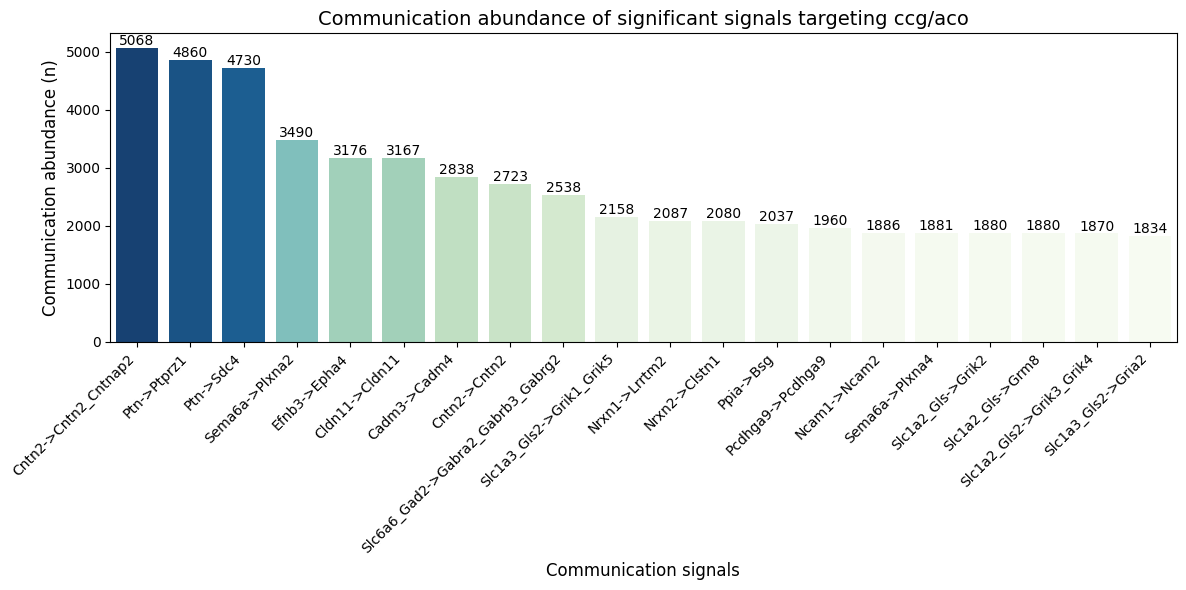

In [ ]:
focus_sig_lrp, path_counts = MC.pl.plot_top_signal_ranked_abundance(
    focus_cell="ccg/aco",
    cell_type=cell_clus,
    sig_pair_res=sig_LR_res,
    top_n=20,
    save=False
)

### Plot the communication strength

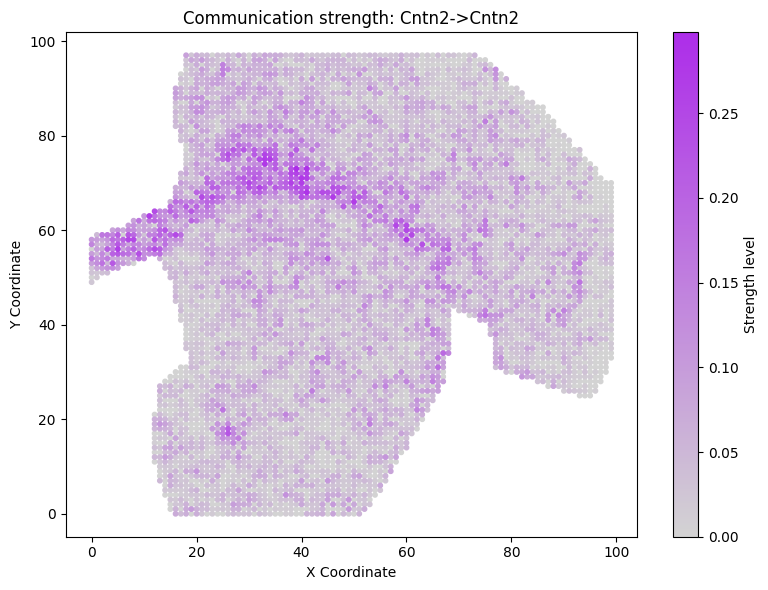

In [ ]:
cell_loc['y'] = cell_loc['y'].max() - cell_loc['y'] # Flip the y-axis
MC.pl.plot_comm_strength(
    comm_item='Cntn2->Cntn2',
    comm_score=sample_inter_df,
    cell_loc=cell_loc,
    cell_clus=cell_clus,
    log_transform=False,
    point_size=10
)

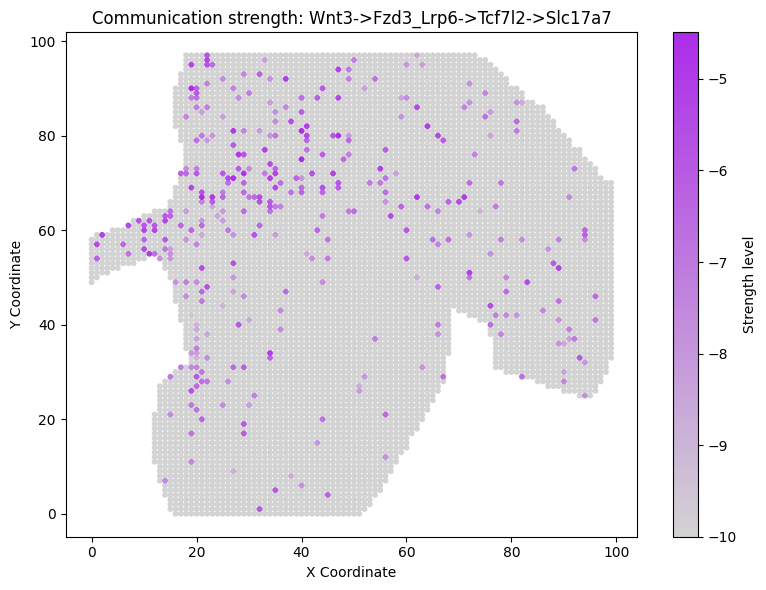

In [ ]:
ccc = pd.read_csv(base_path + 'CCC/L_R_TF_TG/ligand_cascade_results/Wnt3.csv',index_col=0)
# please ensure that the file path is correct and the file exists, 
# or load the results generated from the previous function "Identify_significant_paths_by_gene_role"
MC.pl.plot_comm_strength(
    comm_item='Wnt3->Fzd3_Lrp6->Tcf7l2->Slc17a7',
    comm_score=ccc,
    cell_loc=cell_loc,
    cell_clus=cell_clus,
    scale_factor=1e1,
    log_transform=True,
    point_size=10
)

### Plot the CCC-driven information flow for focused pair/path

In [ ]:
lr_with_pathway = pd.read_csv(base_path + 'inputs/LRpairDB_merge_with_pathway.csv', sep=',') 
lr_with_pathway['LR_Symbol'] = lr_with_pathway['Ligand_Symbol'] + '->' + lr_with_pathway['Receptor_Symbol']
pathway_mapping = lr_with_pathway.set_index('LR_Symbol')['Pathway_Name'].to_dict() 
lr_with_pathway.head()

,Ligand_Symbol,Receptor_Symbol,Pathway_Name,LR_Symbol
0,Tgfb1,Tgfbr1_Tgfbr2,TGFb,Tgfb1->Tgfbr1_Tgfbr2
1,Tgfb2,Tgfbr1_Tgfbr2,TGFb,Tgfb2->Tgfbr1_Tgfbr2
2,Tgfb3,Tgfbr1_Tgfbr2,TGFb,Tgfb3->Tgfbr1_Tgfbr2
3,Tgfb1,Acvr1b_Tgfbr2,TGFb,Tgfb1->Acvr1b_Tgfbr2
4,Tgfb1,Acvr1c_Tgfbr2,TGFb,Tgfb1->Acvr1c_Tgfbr2


In [30]:
color_map = {     
    'ACB': '#ff7f0e',       
    'CP': '#2ca02c',      
    'L1-L3': '#d62728',          
    'L4': '#9467bd',    
    'L5': '#8c564b',        
    'L6a/b': '#e377c2',           
    'VL': '#bcbd22',      
    'ccg/aco': '#17becf'              
}

coord_df = cell_loc.copy() 
coord_df['color'] = cell_clus['cell_type'].map(color_map)

Here, we focus on the information flow of a specific L–R pair.

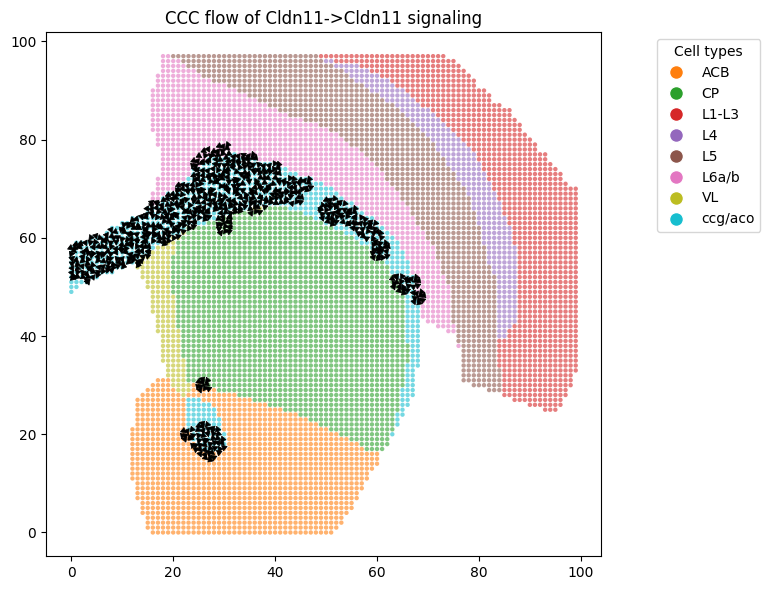

In [ ]:
res_df = MC.pl.plot_ccc_flow_for_signaling(
    pathway_name='Cldn11->Cldn11',
    Sig_LR_path=base_path + 'CCC/Significant_LRs.csv',
    lr_with_pathway=lr_with_pathway,
    cell_clus=cell_clus,
    cell_loc=cell_loc,
    coord_df=coord_df,
    color_map=color_map,
    base_path=base_path,
    point_size=10,
    mode='LR_Symbol'
)

### Plot the information flow for two-hop signaling events 

> For potential two-hop signaling events

Processing paths:  40%|████      | 251907/623138 [00:07<00:11, 33243.07it/s]

Processing paths: 100%|██████████| 623138/623138 [00:18<00:00, 33293.68it/s]


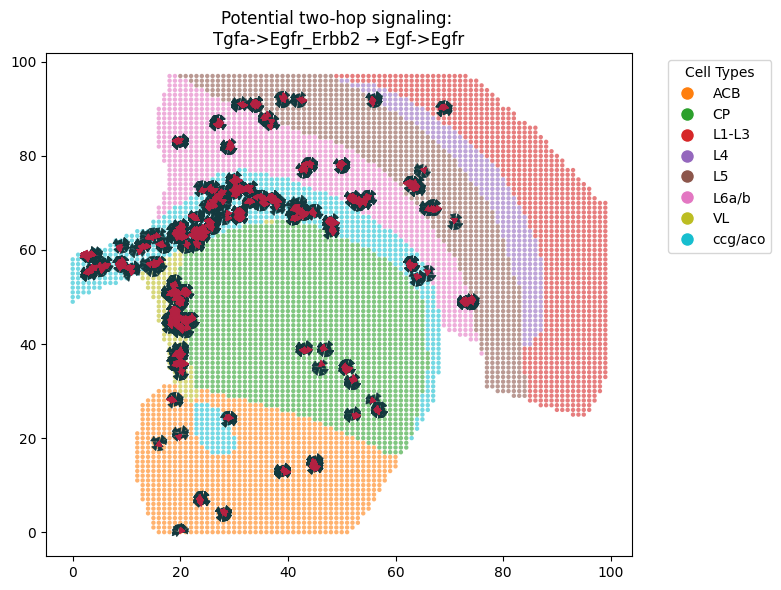

In [34]:
cur_df = MC.pl.plot_two_hop_signaling(
    pathway_name='EGF',
    pair1='Tgfa->Egfr_Erbb2',
    pair2='Egf->Egfr',
    base_path=base_path,
    lr_with_pathway=lr_with_pathway,
    cell_clus=cell_clus,
    cell_loc=cell_loc,
    coord_df=coord_df,
    color_map=color_map,
    point_size=10
)